In [1]:
# ============================================================
# High-Resolution SST Forecasting in the East Sea via SVD-Enhanced NG-RC
# ============================================================
# Author: Azimov Sherkhon Azizkhon Ugli
# Email:  sherxonazimov94@pusan.ac.kr
# GitHub: @AzimovSherkhon
# ============================================================

In [2]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

from sklearn.decomposition import PCA

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# Reproducibility
# ============================================================

seed = 2025

np.random.seed(seed)

In [3]:
# ============================================================
# 1. Load SST Dataset
# ============================================================

sst_data = np.load("sst_normalized_5k.npy")

# Shape:
# (spatial_points, time)

sst_time_major = sst_data.T

print("Original SST shape:", sst_time_major.shape)

Original SST shape: (5001, 2078)


In [4]:
# ============================================================
# 2. Time Setup
# ============================================================
dt = 1.0
warmup   = 100.0
traintime = 3900.0
valtime   = 500.0
testtime  = 500.0

maxtime = warmup + traintime + valtime + testtime

warmup_pts    = int(round(warmup / dt))
traintime_pts = int(round(traintime / dt))
valtime_pts   = int(round(valtime / dt))
testtime_pts  = int(round(testtime / dt))

warmtrain_pts = warmup_pts + traintime_pts
val_end       = warmtrain_pts + valtime_pts
maxtime_pts   = int(round(maxtime / dt))

print("==== Data Splits ====")
print(f"Warmup : {warmup_pts}")
print(f"Train  : {traintime_pts}")
print(f"Val    : {valtime_pts}")
print(f"Test   : {testtime_pts}")

==== Data Splits ====
Warmup : 100
Train  : 3900
Val    : 500
Test   : 500


In [5]:
# ============================================================
# 3. Fit PCA/SVD on TRAINING DATA ONLY
# ============================================================
pca_train_end = warmtrain_pts

n_components = 1

train_sst = sst_time_major[:pca_train_end]

pca = PCA(
    n_components=n_components,
    svd_solver='full'
)

pca.fit(train_sst)

# Transform entire dataset using TRAIN PCA basis
sst_pca = pca.transform(sst_time_major)

explained_variance = pca.explained_variance_ratio_

print("\n==== PCA/SVD Summary ====")
print(f"Retained components      : {n_components}")
print(f"Explained variance ratio : {explained_variance}")


==== PCA/SVD Summary ====
Retained components      : 1
Explained variance ratio : [0.98293175]


In [6]:
# ============================================================
# 4. Prepare Latent SST Dataset
# ============================================================

latent_sst = sst_pca.T

X_soln = latent_sst[:, :maxtime_pts + 1]

d, T_full = X_soln.shape

print(f"\nLatent SST shape: {X_soln.shape}")


Latent SST shape: (1, 5001)


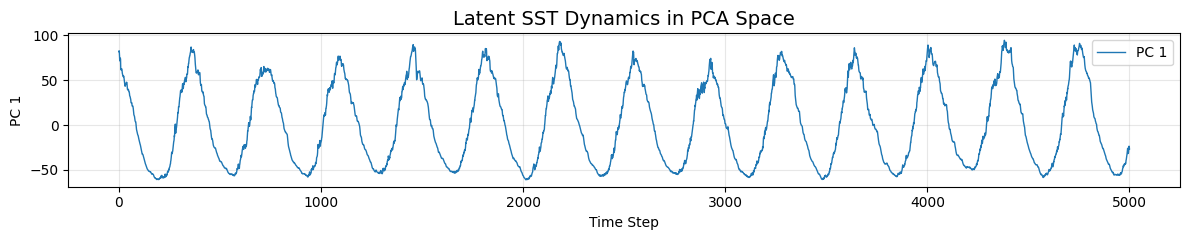

In [7]:
# ============================================================
# Visualization of Latent SST Dynamics (PCA Components)
# ============================================================

# latent_sst shape:
# (n_components, time)

num_components_to_plot = min(n_components, 10)

time = np.arange(latent_sst.shape[1])

plt.figure(figsize=(12, 2.5 * num_components_to_plot))

for i in range(num_components_to_plot):

    plt.subplot(num_components_to_plot, 1, i + 1)

    plt.plot(
        time,
        latent_sst[i],
        linewidth=1.0,
        label=f'PC {i+1}'
    )

    plt.ylabel(f'PC {i+1}')

    plt.grid(True, alpha=0.3)

    plt.legend(loc='upper right')

    if i == 0:
        plt.title(
            "Latent SST Dynamics in PCA Space",
            fontsize=14
        )

    if i == num_components_to_plot - 1:
        plt.xlabel("Time Step")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 5. NG-RC / NVAR Hyperparameter Optimization Configuration
# ============================================================

import time
import optuna
import numpy as np

# Validation configuration
window_size = 90
stride = 1  # fully overlapping rolling windows

# Number of Optuna trials
n_trials = 200

# Store optimization history
results = []


# ============================================================
# 6. Vectorized Feature Construction for NG-RC
# ============================================================

def build_features(data, k, start_idx, end_idx):
    """
    Construct nonlinear vector autoregressive (NVAR) features using vectorization.

    Parameters
    ----------
    data : ndarray
        Input latent-state data with shape (d, T)
    k : int
        Delay embedding dimension
    start_idx : int
        Starting time index
    end_idx : int
        Ending time index (exclusive)

    Returns
    -------
    features : ndarray
        Full NVAR feature matrix of shape (d_total, length)
    linear_block : ndarray
        Delay-coordinate linear features of shape (d_linear, length)
    """
    d, _ = data.shape

    if start_idx < (k - 1):
        raise ValueError("Insufficient history for selected delay dimension k.")

    length = end_idx - start_idx
    d_linear = d * k
    d_quadratic = (d_linear * (d_linear + 1)) // 2
    d_total = 1 + d_linear + d_quadratic

    # 1. Construct Linear Delay Embedding
    linear_block = np.zeros((d_linear, length))
    for delay in range(k):
        linear_block[delay * d : (delay + 1) * d, :] = data[:, start_idx - delay : end_idx - delay]

    # 2. Construct Full Feature Matrix
    features = np.ones((d_total, length))
    features[1 : 1 + d_linear, :] = linear_block

    # 3. Vectorized Quadratic Terms
    r_idx, c_idx = np.triu_indices(d_linear)
    features[1 + d_linear :, :] = linear_block[r_idx, :] * linear_block[c_idx, :]

    return features, linear_block


# ============================================================
# 7. Optuna Objective Function
# ============================================================

def objective(trial):
    # Search Space
    k = trial.suggest_categorical("k", [2, 5, 10, 20, 30, 40, 50])
    ridge_param = trial.suggest_float("ridge", 1e-7, 1e6, log=True)

    d_linear = d * k
    d_quadratic = (d_linear * (d_linear + 1)) // 2
    d_total = 1 + d_linear + d_quadratic

    train_start = warmup_pts - 1
    train_end = warmtrain_pts - 1

    if train_start < (k - 1):
        return np.inf

    # --- Training Phase ---
    train_features, _ = build_features(X_soln, k, train_start, train_end)
    delta_x = X_soln[:, warmup_pts:warmtrain_pts] - X_soln[:, warmup_pts - 1 : warmtrain_pts - 1]

    # Ridge Regression Solution
    cov_matrix = train_features @ train_features.T
    reg_matrix = cov_matrix + ridge_param * np.eye(d_total)

    try:
        # Solve (W_out @ reg_matrix) = (delta_x @ train_features.T)
        W_out = np.linalg.solve(reg_matrix.T, (delta_x @ train_features.T).T).T
    except np.linalg.LinAlgError:
        W_out = delta_x @ train_features.T @ np.linalg.pinv(reg_matrix)

    # Pre-index upper-triangular elements for fast test feature construction
    r_idx, c_idx = np.triu_indices(d_linear)

    # --- Validation Phase ---
    validation_mses, validation_maes, validation_rmses = [], [], []

    for start in range(warmtrain_pts, val_end - window_size + 1, stride):
        end = start + window_size

        # Initialize Delay History
        history = [X_soln[:, start - k + i].copy() for i in range(k)]
        prediction = np.zeros((d, window_size))

        # Autonomous Rollout
        for step in range(window_size):
            z = np.hstack([history[-1 - delay] for delay in range(k)])

            test_features = np.ones(d_total)
            test_features[1 : 1 + d_linear] = z
            test_features[1 + d_linear :] = z[r_idx] * z[c_idx]

            delta_pred = W_out @ test_features
            next_state = history[-1] + delta_pred

            prediction[:, step] = next_state
            history.append(next_state)

        # Validation Metrics
        truth = X_soln[:, start:end]
        mse = np.mean((truth - prediction) ** 2)
        mae = np.mean(np.abs(truth - prediction))
        rmse = np.sqrt(mse)

        validation_mses.append(mse)
        validation_maes.append(mae)
        validation_rmses.append(rmse)

    # --- Aggregate Scores ---
    avg_mse = np.mean(validation_mses) if validation_mses else np.inf
    avg_mae = np.mean(validation_maes) if validation_maes else np.inf
    avg_rmse = np.mean(validation_rmses) if validation_rmses else np.inf

    results.append({
        "k": k,
        "ridge": ridge_param,
        "mse": avg_mse,
        "mae": avg_mae,
        "rmse": avg_rmse
    })

    print(
        f"Trial {trial.number:03d} | "
        f"k = {k:<2d} | "
        f"ridge = {ridge_param:>10.2e} | "
        f"MSE = {avg_mse:.6f} | "
        f"MAE = {avg_mae:.6f} | "
        f"RMSE = {avg_rmse:.6f}"
    )

    return avg_rmse


# ============================================================
# 8. Run Optuna Optimization
# ============================================================

start_time = time.time()
print("\n==== NG-RC Hyperparameter Optimization ====\n")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)

study.optimize(
    objective,
    n_trials=n_trials,
    show_progress_bar=True
)


# ============================================================
# 9. Best Hyperparameters Summary
# ============================================================

best_k = study.best_params["k"]
best_ridge = study.best_params["ridge"]
best_rmse = study.best_value

best_result = min(results, key=lambda x: x["rmse"])
best_mse = best_result["mse"]
best_mae = best_result["mae"]

print("\n==== Optimal NG-RC Configuration ====\n")
print(f"Optimal delay dimension (k) : {best_k}")
print(f"Optimal ridge parameter     : {best_ridge:.2e}")
print(f"Best validation MSE         : {best_mse:.6f}")
print(f"Best validation MAE         : {best_mae:.6f}")
print(f"Best validation RMSE        : {best_rmse:.6f}")
print(f"Execution time              : {time.time() - start_time:.2f} seconds")

[I 2026-07-26 21:55:33,270] A new study created in memory with name: no-name-e198594b-806b-48b1-95d4-671b6fc06901



==== NG-RC Hyperparameter Optimization ====



  0%|          | 0/200 [00:00<?, ?it/s]

Trial 000 | k = 10 | ridge =   2.54e-01 | MSE = 758.062711 | MAE = 20.708320 | RMSE = 24.812108
[I 2026-07-26 21:55:33,780] Trial 0 finished with value: 24.812108249555013 and parameters: {'k': 10, 'ridge': 0.25352464752029175}. Best is trial 0 with value: 24.812108249555013.
Trial 001 | k = 2  | ridge =   6.41e-04 | MSE = 1362.086070 | MAE = 29.526366 | RMSE = 34.598459
[I 2026-07-26 21:55:34,165] Trial 1 finished with value: 34.59845936202017 and parameters: {'k': 2, 'ridge': 0.0006405043692191096}. Best is trial 0 with value: 24.812108249555013.


/tmp/ipykernel_107685/3564220722.py:124: RuntimeWarning: overflow encountered in multiply
  test_features[1 + d_linear :] = z[r_idx] * z[c_idx]
/tmp/ipykernel_107685/3564220722.py:126: RuntimeWarning: invalid value encountered in matmul
  delta_pred = W_out @ test_features
/tmp/ipykernel_107685/3564220722.py:134: RuntimeWarning: overflow encountered in square
  mse = np.mean((truth - prediction) ** 2)


Trial 002 | k = 40 | ridge =   4.01e-06 | MSE = nan | MAE = nan | RMSE = nan
[W 2026-07-26 21:55:35,290] Trial 2 failed with parameters: {'k': 40, 'ridge': 4.006230508002568e-06} because of the following error: The value nan is not acceptable.
[W 2026-07-26 21:55:35,291] Trial 2 failed with value nan.
Trial 003 | k = 5  | ridge =   7.62e+05 | MSE = 1359.994667 | MAE = 29.273069 | RMSE = 34.252953
[I 2026-07-26 21:55:35,716] Trial 3 finished with value: 34.25295281394383 and parameters: {'k': 5, 'ridge': 761517.1767224498}. Best is trial 0 with value: 24.812108249555013.
Trial 004 | k = 50 | ridge =   1.29e-02 | MSE = nan | MAE = nan | RMSE = nan
[W 2026-07-26 21:55:37,058] Trial 4 failed with parameters: {'k': 50, 'ridge': 0.012862009967543995} because of the following error: The value nan is not acceptable.
[W 2026-07-26 21:55:37,059] Trial 4 failed with value nan.
Trial 005 | k = 2  | ridge =   2.65e-03 | MSE = 1362.086075 | MAE = 29.526365 | RMSE = 34.598459
[I 2026-07-26 21:55:37,4

In [9]:
# ============================================================
# 8. Select Optimal NG-RC Model
# ============================================================

valid_results = [r for r in results if np.isfinite(r["rmse"])]

if not valid_results:
    raise RuntimeError("No valid hyperparameter configuration found.")

best_result = min(valid_results, key=lambda r: r["rmse"])

best_k = best_result["k"]
best_ridge = best_result["ridge"]
best_mse = best_result["mse"]
best_mae = best_result["mae"]
best_rmse = best_result["rmse"]

print("\n==== Optimal NG-RC Configuration ====\n")
print(f"Delay dimension (k)    : {best_k}")
print(f"Ridge regularization   : {best_ridge:.2e}")
print(f"Validation MSE         : {best_mse:.6f}")
print(f"Validation MAE         : {best_mae:.6f}")
print(f"Validation RMSE        : {best_rmse:.6f}")


# ============================================================
# 9. Retrain NG-RC Using Optimal Hyperparameters
# ============================================================

train_start = warmup_pts - 1
train_end = warmtrain_pts - 1

# Construct NVAR training features
train_features, _ = build_features(X_soln, best_k, train_start, train_end)

# One-step latent increments
delta_x = X_soln[:, warmup_pts:warmtrain_pts] - X_soln[:, warmup_pts - 1 : warmtrain_pts - 1]

# Feature Dimensions
d_linear = d * best_k
d_quadratic = (d_linear * (d_linear + 1)) // 2
d_total = 1 + d_linear + d_quadratic

# Ridge Regression System
cov_matrix = train_features @ train_features.T
reg_matrix = cov_matrix + best_ridge * np.eye(d_total)

try:
    W_out = np.linalg.solve(reg_matrix.T, (delta_x @ train_features.T).T).T
except np.linalg.LinAlgError:
    W_out = delta_x @ train_features.T @ np.linalg.pinv(reg_matrix)


# ============================================================
# 10. Autonomous Forecast Evaluation on TEST Dataset
# ============================================================

test_start = val_end
test_end = maxtime_pts

window_size = 90
stride = 1
horizons = [10, 30, 60, 90]

# Containers (Latent Space)
all_true, all_pred = [], []
all_mse, all_mae, all_rmse = [], [], []

# Containers (Original SST Space)
all_rec_sst, all_true_sst = [], []
all_mse_sst, all_mae_sst, all_rmse_sst = [], [], []

# ============================================================
# Persistence Baseline (SST Space)
# ============================================================

all_persist_mse_sst = []
all_persist_mae_sst = []
all_persist_rmse_sst = []

horizon_persist_mses_sst = {h: [] for h in horizons}
horizon_persist_maes_sst = {h: [] for h in horizons}

# Horizon-wise Storage
horizon_mses = {h: [] for h in horizons}
horizon_maes = {h: [] for h in horizons}
horizon_sst_mses = {h: [] for h in horizons}
horizon_sst_maes = {h: [] for h in horizons}

# Pre-index upper-triangular terms for fast vectorization in rollout
r_idx, c_idx = np.triu_indices(d_linear)

print("\n==== NG-RC TEST Evaluation ====\n")

for start in range(test_start, test_end - window_size + 1, stride):
    end = start + window_size

    # Initialize Delay History
    history = [X_soln[:, start - best_k + i].copy() for i in range(best_k)]
    prediction = np.zeros((d, window_size))

    # Autonomous Rollout
    for step in range(window_size):
        z = np.hstack([history[-1 - delay] for delay in range(best_k)])

        test_features = np.ones(d_total)
        test_features[1 : 1 + d_linear] = z
        test_features[1 + d_linear :] = z[r_idx] * z[c_idx]

        delta_pred = W_out @ test_features
        next_state = history[-1] + delta_pred

        prediction[:, step] = next_state
        history.append(next_state)

    truth = X_soln[:, start:end]

    # Reconstruct SST Fields
    predicted_pcs = prediction.T
    reconstructed_sst = pca.inverse_transform(predicted_pcs)
    true_sst = sst_time_major[start:end]
    
    # Standard Persistence Forecast (SST Space)
    persistent_sst = np.repeat(true_sst[0][None, :], window_size, axis=0)

    all_rec_sst.append(reconstructed_sst)
    all_true_sst.append(true_sst)

    # Point-in-Time Horizon Errors
    for h in horizons:
        if h > window_size:
            continue

        idx = h - 1  # Target exact lead step

        # Latent Space (per-variable error at lead step h)
        horizon_mses[h].append((truth[:, idx] - prediction[:, idx]) ** 2)
        horizon_maes[h].append(np.abs(truth[:, idx] - prediction[:, idx]))

        # Reconstructed SST Space (spatial average error at lead step h)
        horizon_sst_mses[h].append((true_sst[idx] - reconstructed_sst[idx]) ** 2)
        horizon_sst_maes[h].append(np.abs(true_sst[idx] - reconstructed_sst[idx]))
        
        # Persistence Baseline
        horizon_persist_mses_sst[h].append((true_sst[idx] - persistent_sst[idx]) ** 2)
        horizon_persist_maes_sst[h].append(np.abs(true_sst[idx] - persistent_sst[idx]))
        
    # Full-window Errors
    # Latent Space
    full_mse = np.mean((truth - prediction) ** 2)
    full_mae = np.mean(np.abs(truth - prediction))
    full_rmse = np.sqrt(full_mse)

    all_mse.append(full_mse)
    all_mae.append(full_mae)
    all_rmse.append((start, end, full_rmse))

    # SST Space
    full_mse_sst = np.mean((true_sst - reconstructed_sst) ** 2)
    full_mae_sst = np.mean(np.abs(true_sst - reconstructed_sst))
    full_rmse_sst = np.sqrt(full_mse_sst)

    # Persistence Baseline (Full Window)
    persist_mse_sst = np.mean((true_sst - persistent_sst) ** 2)
    persist_mae_sst = np.mean(np.abs(true_sst - persistent_sst))
    persist_rmse_sst = np.sqrt(persist_mse_sst)

    all_persist_mse_sst.append(persist_mse_sst)
    all_persist_mae_sst.append(persist_mae_sst)
    all_persist_rmse_sst.append((start, end, persist_rmse_sst))

    all_mse_sst.append(full_mse_sst)
    all_mae_sst.append(full_mae_sst)
    all_rmse_sst.append((start, end, full_rmse_sst))

    all_true.append(truth)
    all_pred.append(prediction)


# ============================================================
# 11. Aggregate Array Formatting
# ============================================================

all_true = np.hstack(all_true) if all_true else np.empty((d, 0))
all_pred = np.hstack(all_pred) if all_pred else np.empty((d, 0))
all_rec_sst = np.concatenate(all_rec_sst) if all_rec_sst else np.empty((0, sst_time_major.shape[1]))
all_true_sst = np.concatenate(all_true_sst) if all_true_sst else np.empty((0, sst_time_major.shape[1]))


# ============================================================
# 12. Horizon-wise Forecast Skill Summary
# ============================================================

latent_variables = [f"PC {i+1}" for i in range(d)]

# --- 1. LATENT SPACE METRICS ---
print("\n" + "=" * 60)
print("  TEST Horizon-wise Forecast Skill (LATENT SPACE)")
print("=" * 60)

for h in horizons:
    if not horizon_mses[h]:
        continue

    mse_array = np.vstack(horizon_mses[h])
    mae_array = np.vstack(horizon_maes[h])

    mean_mse_per_variable = np.mean(mse_array, axis=0)
    mean_mae_per_variable = np.mean(mae_array, axis=0)
    rmse_per_variable = np.sqrt(mean_mse_per_variable)

    overall_mse = np.mean(mean_mse_per_variable)
    overall_mae = np.mean(mean_mae_per_variable)
    overall_rmse = np.sqrt(overall_mse)

    print(f"\n-- Forecast Horizon: Step {h} --")
    for i, var in enumerate(latent_variables):
        print(f"{var:<8} | MSE : {mean_mse_per_variable[i]:.6f} | MAE : {mean_mae_per_variable[i]:.6f} | RMSE : {rmse_per_variable[i]:.6f}")

    print(f"Overall   | MSE : {overall_mse:.6f} | MAE : {overall_mae:.6f} | RMSE : {overall_rmse:.6f}")


# --- 2. RECONSTRUCTED SST SPACE METRICS ---
print("\n" + "=" * 60)
print("  TEST Horizon-wise Forecast Skill (RECONSTRUCTED SST)")
print("=" * 60)

for h in horizons:
    if not horizon_sst_mses[h]:
        continue

    # NG-RC
    mse_array_sst = np.vstack(horizon_sst_mses[h])
    mae_array_sst = np.vstack(horizon_sst_maes[h])

    overall_mse_sst = np.mean(mse_array_sst)
    overall_mae_sst = np.mean(mae_array_sst)
    overall_rmse_sst = np.sqrt(overall_mse_sst)

    # Persistence
    persist_mse = np.mean(np.vstack(horizon_persist_mses_sst[h]))
    persist_mae = np.mean(np.vstack(horizon_persist_maes_sst[h]))
    persist_rmse = np.sqrt(persist_mse)

    # Percentage Improvements (Positive means NG-RC is better)
    imp_mse = ((persist_mse - overall_mse_sst) / persist_mse) * 100
    imp_mae = ((persist_mae - overall_mae_sst) / persist_mae) * 100
    imp_rmse = ((persist_rmse - overall_rmse_sst) / persist_rmse) * 100

    print(f"\n-- Forecast Horizon: Step {h} --")
    print(f"NG-RC       | MSE : {overall_mse_sst:.6f} | MAE : {overall_mae_sst:.6f} | RMSE : {overall_rmse_sst:.6f}")
    print(f"Persistence | MSE : {persist_mse:.6f} | MAE : {persist_mae:.6f} | RMSE : {persist_rmse:.6f}")
    print(f"Improvement | MSE : {imp_mse:+.2f}%   | MAE : {imp_mae:+.2f}%   | RMSE : {imp_rmse:+.2f}%")


# --- 3. OVERALL TEST SUMMARY ---
print("\n" + "=" * 60)
print("  Overall TEST Summary (Full Window Averages)")
print("=" * 60 + "\n")

overall_ng_mse_sst = np.mean(all_mse_sst)
overall_ng_mae_sst = np.mean(all_mae_sst)
overall_ng_rmse_sst = np.mean([x[2] for x in all_rmse_sst])

overall_per_mse_sst = np.mean(all_persist_mse_sst)
overall_per_mae_sst = np.mean(all_persist_mae_sst)
overall_per_rmse_sst = np.mean([x[2] for x in all_persist_rmse_sst])

# Overall Improvements
overall_imp_mse = ((overall_per_mse_sst - overall_ng_mse_sst) / overall_per_mse_sst) * 100
overall_imp_mae = ((overall_per_mae_sst - overall_ng_mae_sst) / overall_per_mae_sst) * 100
overall_imp_rmse = ((overall_per_rmse_sst - overall_ng_rmse_sst) / overall_per_rmse_sst) * 100

print(f"Latent Space (NG-RC)  | MSE : {np.mean(all_mse):.6f} | MAE : {np.mean(all_mae):.6f} | RMSE : {np.mean([x[2] for x in all_rmse]):.6f}")
print(f"SST Space (NG-RC)     | MSE : {overall_ng_mse_sst:.6f} | MAE : {overall_ng_mae_sst:.6f} | RMSE : {overall_ng_rmse_sst:.6f}")
print(f"SST Space (Persist)   | MSE : {overall_per_mse_sst:.6f} | MAE : {overall_per_mae_sst:.6f} | RMSE : {overall_per_rmse_sst:.6f}")
print(f"Improvement vs Pers.  | MSE : {overall_imp_mse:+.2f}%   | MAE : {overall_imp_mae:+.2f}%   | RMSE : {overall_imp_rmse:+.2f}%")

print("-" * 60)
print(f"TEST Window Size   : {window_size}")
print(f"TEST Stride        : {stride}")
print(f"Total TEST Windows : {len(all_rmse)}")
print("=" * 60)



==== Optimal NG-RC Configuration ====

Delay dimension (k)    : 20
Ridge regularization   : 1.56e+05
Validation MSE         : 593.302846
Validation MAE         : 17.139522
Validation RMSE        : 20.372637

==== NG-RC TEST Evaluation ====


  TEST Horizon-wise Forecast Skill (LATENT SPACE)

-- Forecast Horizon: Step 10 --
PC 1     | MSE : 33.810462 | MAE : 3.988802 | RMSE : 5.814676
Overall   | MSE : 33.810462 | MAE : 3.988802 | RMSE : 5.814676

-- Forecast Horizon: Step 30 --
PC 1     | MSE : 202.732444 | MAE : 11.212475 | RMSE : 14.238414
Overall   | MSE : 202.732444 | MAE : 11.212475 | RMSE : 14.238414

-- Forecast Horizon: Step 60 --
PC 1     | MSE : 867.784693 | MAE : 24.010458 | RMSE : 29.458185
Overall   | MSE : 867.784693 | MAE : 24.010458 | RMSE : 29.458185

-- Forecast Horizon: Step 90 --
PC 1     | MSE : 1537.544024 | MAE : 32.219413 | RMSE : 39.211529
Overall   | MSE : 1537.544024 | MAE : 32.219413 | RMSE : 39.211529

  TEST Horizon-wise Forecast Skill (RECONSTRUCTED SST)

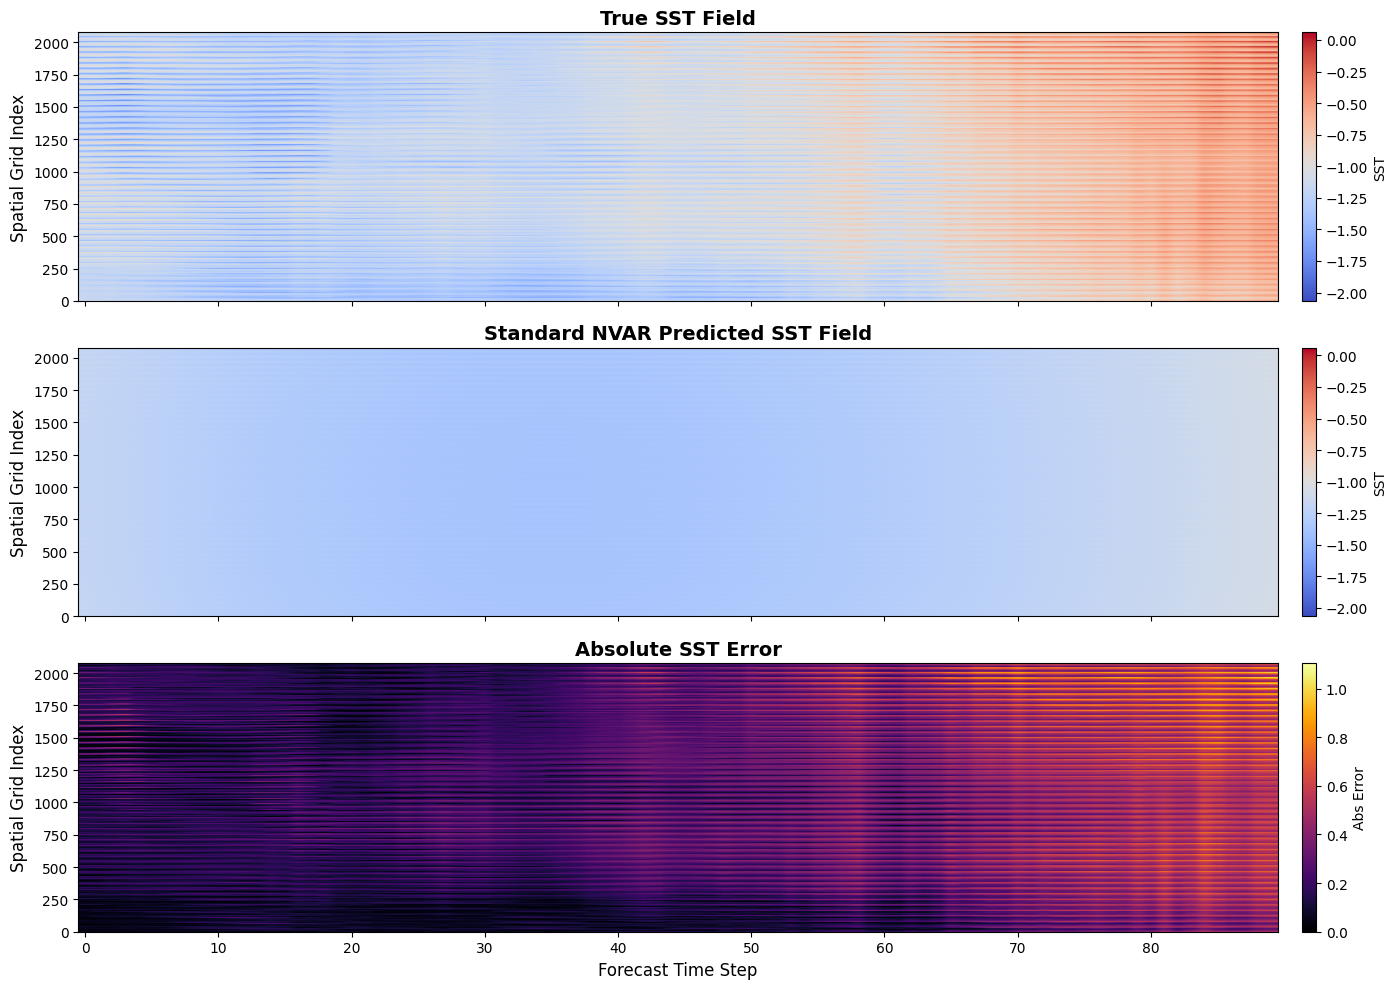

In [10]:
# ============================================================
# Continuous Autonomous SST Forecast Visualization
# Standard NVAR
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. FORECAST LENGTH & EVALUATION SETUP
# ============================================================

plot_len = 90

window_idx = 60      # 0 = first window, 1 = second, ...
test_stride = 1

test_start = val_end + window_idx * test_stride
# Initialize Delay History
history = [
    X_soln[:, test_start - best_k + i].copy()
    for i in range(best_k)
]

# Feature Dimensions & Pre-indexed Upper-Triangular Mapping
d_linear = d * best_k
d_quadratic = (d_linear * (d_linear + 1)) // 2
d_total = 1 + d_linear + d_quadratic

r_idx, c_idx = np.triu_indices(d_linear)

# ============================================================
# 2. CONTINUOUS AUTONOMOUS ROLLOUT
# ============================================================

continuous_pred = np.zeros((d, plot_len))

for j in range(plot_len):

    # Delay Embedding Vector
    z = np.hstack([history[-1 - i] for i in range(best_k)])

    # Construct NVAR Feature Vector
    out_test = np.ones(d_total)
    out_test[1 : 1 + d_linear] = z
    out_test[1 + d_linear :] = z[r_idx] * z[c_idx]

    # Predict Increment & Advance State
    delta_pred = W_out @ out_test
    next_x = history[-1] + delta_pred

    # Store Prediction & Update History
    continuous_pred[:, j] = next_x
    history.append(next_x)

# ============================================================
# 3. RECONSTRUCT SST FIELDS & ERROR
# ============================================================

pc_pred = continuous_pred.T
pred_field = pca.inverse_transform(pc_pred)
true_field = sst_time_major[test_start : test_start + plot_len]

# Absolute SST Error
sst_error = np.abs(true_field - pred_field)

# Enforce shared color scale for True and Predicted fields
vmin_sst = min(true_field.min(), pred_field.min())
vmax_sst = max(true_field.max(), pred_field.max())

# ============================================================
# 4. SUBPLOTS SETUP
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# --- TRUE SST FIELD ---
im0 = axes[0].imshow(
    true_field.T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',
    vmin=vmin_sst,
    vmax=vmax_sst
)
axes[0].set_title('True SST Field', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Spatial Grid Index', fontsize=12)

# --- PREDICTED SST FIELD ---
im1 = axes[1].imshow(
    pred_field.T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',
    vmin=vmin_sst,
    vmax=vmax_sst
)
axes[1].set_title('Standard NVAR Predicted SST Field', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Spatial Grid Index', fontsize=12)

# --- ABSOLUTE ERROR FIELD ---
im2 = axes[2].imshow(
    sst_error.T,
    aspect='auto',
    origin='lower',
    cmap='inferno',
    vmin=0,
    vmax=sst_error.max()
)
axes[2].set_title('Absolute SST Error', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Forecast Time Step', fontsize=12)
axes[2].set_ylabel('Spatial Grid Index', fontsize=12)

# ============================================================
# 5. COLORBARS & EXPORT
# ============================================================

cbar0 = fig.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)
cbar0.set_label('SST', fontsize=10)

cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)
cbar1.set_label('SST', fontsize=10)

cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.02, pad=0.02)
cbar2.set_label('Abs Error', fontsize=10)

plt.tight_layout()

plt.savefig(
    "standard_nvar_sst_field_evolution_Yellow_Sea.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()